# Autoencoder on MNIST
Load local MNIST data, inject artificial noise, and compare the denoising performance of a Linear (Dense) Autoencoder vs a Convolutional Autoencoder.

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import SubsetRandomSampler

torch.manual_seed(42)

## 1. Loading the Dataset

First, we load the MNIST dataset from the local `data` folder. Once loaded, we verify the dataset by checking the image dimensions, data type, pixel value range, and the total number of batches for the training, validation, and test sets.

In [28]:
batch_sz=128
transform=transforms.ToTensor()

train_ds=datasets.MNIST(root='./data',train=True,download=True,transform=transform)
test_ds=datasets.MNIST(root='./data',train=False,download=True,transform=transform)

valid_size=0.2
train_length=len(train_ds)
indices=list(range(train_length))
np.random.shuffle(indices)
split=int(np.floor(valid_size*train_length))
train_idx,valid_idx=indices[split:],indices[:split]

train_sampler=SubsetRandomSampler(train_idx)
valid_sampler=SubsetRandomSampler(valid_idx)

train_loader=torch.utils.data.DataLoader(dataset=train_ds,batch_size=batch_sz,sampler=train_sampler,num_workers=0)
valid_loader=torch.utils.data.DataLoader(dataset=train_ds,batch_size=batch_sz,sampler=valid_sampler,num_workers=0)
test_loader=torch.utils.data.DataLoader(dataset=test_ds,batch_size=batch_sz,shuffle=False)

sample_img,sample_lbl=train_ds[0]
print("--- Data Matrix Analysis ---")
print(f"Tensor Shape: {sample_img.shape}")
print(f"Data Type: {sample_img.dtype}")
print(f"Max Pixel Value: {sample_img.max().item()}")
print(f"Min Pixel Value: {sample_img.min().item()}")
print(f"\nLoaders Length -> Train: {len(train_loader)}, Valid: {len(valid_loader)}, Test: {len(test_loader)}")

--- Data Matrix Analysis ---
Tensor Shape: torch.Size([1, 28, 28])
Data Type: torch.float32
Max Pixel Value: 1.0
Min Pixel Value: 0.0

Loaders Length -> Train: 375, Valid: 94, Test: 79


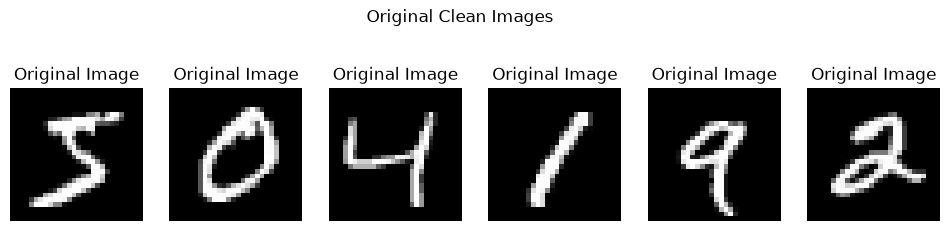

In [ ]:
fig,axes=plt.subplots(1,6,figsize=(12,4))
fig.suptitle('Original Clean Images')
for i in range(6):
    img,_=train_ds[i]
    axes[i].imshow(img.squeeze(),cmap='gray')
    axes[i].set_title("Original Image")
    axes[i].axis('off')
plt.show()

## 2. Artificial Noise Injection

To simulate real-world noisy images, Gaussian noise is added to the original MNIST images.

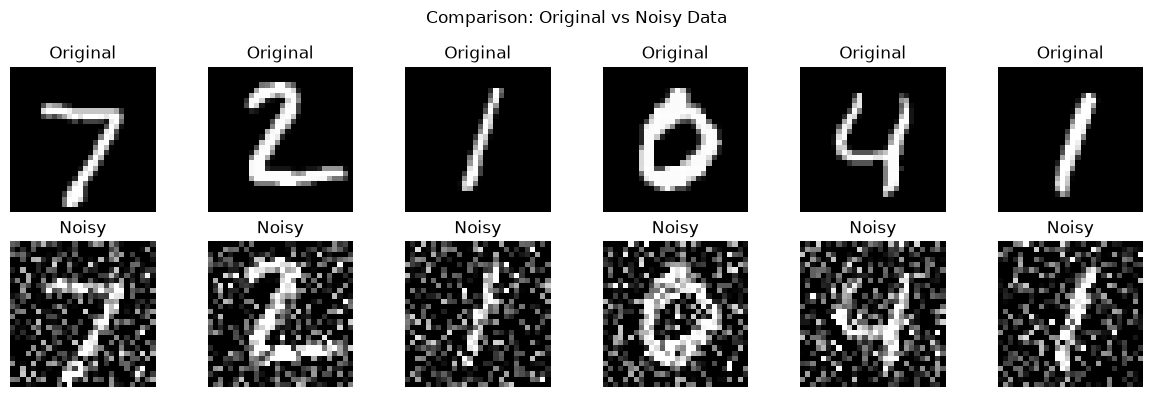

In [56]:
noise_fct=0.4

def inject_noise(imgs):
    noisy=imgs+noise_fct*torch.randn(*imgs.shape).to(imgs.device)
    noisy=torch.clamp(noisy,0.,1.)
    return noisy

test_imgs,_=next(iter(test_loader))
noisy_test_imgs=inject_noise(test_imgs)

fig,axes=plt.subplots(2,6,figsize=(12,4))
fig.suptitle('Comparison: Original vs Noisy Data')
for i in range(6):
    axes[0,i].imshow(test_imgs[i].squeeze().cpu(),cmap='gray')
    axes[0,i].set_title("Original")
    axes[0,i].axis('off')
    axes[1,i].imshow(noisy_test_imgs[i].squeeze().cpu(),cmap='gray')
    axes[1,i].set_title("Noisy")
    axes[1,i].axis('off')
plt.tight_layout()
plt.show()

## 3. Autoencoder Models

In this step, we build and compare two different autoencoder models for image denoising.

- **Dense Autoencoder (DenseAutoEncoder):** Uses fully connected (linear) layers to learn and reconstruct the input images.
- **Convolutional Autoencoder (ConvAutoEncoder):** Uses convolutional layers to capture spatial features and produce better image reconstruction.
- Both models are trained using the same noisy and clean image pairs.
- Finally, the performance of both models is compared to identify which architecture removes noise more effectively.

Dense Autoencoder

In [57]:
class DenseAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc=nn.Sequential(
            nn.Linear(28*28,128),
            nn.ReLU(),
            nn.Linear(128,32),
            nn.ReLU()
        )
        self.dec=nn.Sequential(
            nn.Linear(32,128),
            nn.ReLU(),
            nn.Linear(128,28*28),
            nn.Sigmoid()
        )
    def forward(self,x):
        x=x.view(-1,28*28)
        x=self.enc(x)
        x=self.dec(x)
        x=x.view(-1,1,28,28)
        return x


Convolutional AutoEncoder

In [58]:
class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc=nn.Sequential(
            nn.Conv2d(1,16,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,32,3,stride=2,padding=1),
            nn.ReLU()
        )
        self.dec=nn.Sequential(
            nn.ConvTranspose2d(32,16,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16,1,3,stride=2,padding=1,output_padding=1),
            nn.Sigmoid()
        )
    def forward(self,x):
        x=self.enc(x)
        x=self.dec(x)
        return x

In [59]:
dev=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_dense=DenseAutoEncoder().to(dev)
model_conv=ConvAutoEncoder().to(dev)

print("--- Model Architectures ---")
print("Dense Model:",model_dense)
print("\nConv Model:",model_conv)
print(f"\nUsing device: {dev}")

--- Model Architectures ---
Dense Model: DenseAutoEncoder(
  (enc): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=32, bias=True)
    (3): ReLU()
  )
  (dec): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

Conv Model: ConvAutoEncoder(
  (enc): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (dec): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

Using device: cuda


## 4. Training & Validation Setup
Training both models to benchmark their denoising capabilities.## 4. Training and Validation

In this step, both autoencoder models are trained using the same training pipeline to ensure a fair comparison.

- **Loss Function:** Mean Squared Error (MSE) Loss is used to measure the difference between the reconstructed and original images.
- **Optimizer:** Adam optimizer is used with a learning rate of **0.0005** for efficient model optimization.
- During each training iteration, Gaussian noise is added to the input images before passing them to the model.

In [32]:
crit=nn.MSELoss()
opt_dense=optim.Adam(model_dense.parameters(),lr=0.0005)
opt_conv=optim.Adam(model_conv.parameters(),lr=0.0005)

def train_model(model,optimizer,epochs=20):
    print(f"\nTraining {type(model).__name__}...")
    history={'train':[],'valid':[]}

    valid_loss_min=float('inf') 
    
    for ep in range(epochs):
        tot_train_loss=0
        model.train()
        for imgs,_ in train_loader:
            imgs=imgs.to(dev)
            noisy=inject_noise(imgs)
            
            preds=model(noisy)
            loss=crit(preds,imgs)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            tot_train_loss+=loss.item()
            
        # Validation Phase
        tot_valid_loss=0
        model.eval()
        with torch.no_grad():
            for imgs,_ in valid_loader:
                imgs=imgs.to(dev)
                noisy=inject_noise(imgs)
                preds=model(noisy)
                loss=crit(preds,imgs)
                tot_valid_loss+=loss.item()
                
        avg_train=tot_train_loss/len(train_loader)
        avg_valid=tot_valid_loss/len(valid_loader)
        
        history['train'].append(avg_train)
        history['valid'].append(avg_valid)
        
        print(f"Epoch {ep+1}/{epochs} | Train Loss: {avg_train:.4f} | Valid Loss: {avg_valid:.4f}")
        
        if avg_valid<=valid_loss_min:
            torch.save(model.state_dict(),type(model).__name__+'_best.pth')
            valid_loss_min=avg_valid
            
    return history

In [33]:
loss_dense=train_model(model_dense,opt_dense)


Training DenseAutoEncoder...
Epoch 1/20 | Train Loss: 0.0717 | Valid Loss: 0.0529
Epoch 2/20 | Train Loss: 0.0441 | Valid Loss: 0.0380
Epoch 3/20 | Train Loss: 0.0348 | Valid Loss: 0.0328
Epoch 4/20 | Train Loss: 0.0311 | Valid Loss: 0.0297
Epoch 5/20 | Train Loss: 0.0287 | Valid Loss: 0.0276
Epoch 6/20 | Train Loss: 0.0267 | Valid Loss: 0.0257
Epoch 7/20 | Train Loss: 0.0250 | Valid Loss: 0.0242
Epoch 8/20 | Train Loss: 0.0237 | Valid Loss: 0.0232
Epoch 9/20 | Train Loss: 0.0227 | Valid Loss: 0.0223
Epoch 10/20 | Train Loss: 0.0220 | Valid Loss: 0.0217
Epoch 11/20 | Train Loss: 0.0214 | Valid Loss: 0.0211
Epoch 12/20 | Train Loss: 0.0208 | Valid Loss: 0.0206
Epoch 13/20 | Train Loss: 0.0203 | Valid Loss: 0.0201
Epoch 14/20 | Train Loss: 0.0199 | Valid Loss: 0.0197
Epoch 15/20 | Train Loss: 0.0196 | Valid Loss: 0.0194
Epoch 16/20 | Train Loss: 0.0192 | Valid Loss: 0.0192
Epoch 17/20 | Train Loss: 0.0190 | Valid Loss: 0.0190
Epoch 18/20 | Train Loss: 0.0187 | Valid Loss: 0.0186
Epoch 1

In [34]:
loss_conv=train_model(model_conv,opt_conv)


Training ConvAutoEncoder...
Epoch 1/20 | Train Loss: 0.0678 | Valid Loss: 0.0133
Epoch 2/20 | Train Loss: 0.0116 | Valid Loss: 0.0107
Epoch 3/20 | Train Loss: 0.0104 | Valid Loss: 0.0101
Epoch 4/20 | Train Loss: 0.0100 | Valid Loss: 0.0098
Epoch 5/20 | Train Loss: 0.0098 | Valid Loss: 0.0097
Epoch 6/20 | Train Loss: 0.0096 | Valid Loss: 0.0096
Epoch 7/20 | Train Loss: 0.0095 | Valid Loss: 0.0094
Epoch 8/20 | Train Loss: 0.0095 | Valid Loss: 0.0094
Epoch 9/20 | Train Loss: 0.0094 | Valid Loss: 0.0093
Epoch 10/20 | Train Loss: 0.0093 | Valid Loss: 0.0092
Epoch 11/20 | Train Loss: 0.0092 | Valid Loss: 0.0092
Epoch 12/20 | Train Loss: 0.0092 | Valid Loss: 0.0091
Epoch 13/20 | Train Loss: 0.0091 | Valid Loss: 0.0090
Epoch 14/20 | Train Loss: 0.0091 | Valid Loss: 0.0090
Epoch 15/20 | Train Loss: 0.0090 | Valid Loss: 0.0089
Epoch 16/20 | Train Loss: 0.0090 | Valid Loss: 0.0089
Epoch 17/20 | Train Loss: 0.0089 | Valid Loss: 0.0089
Epoch 18/20 | Train Loss: 0.0089 | Valid Loss: 0.0089
Epoch 19

## 5. Performance Comparison & Visualization
Testing both models on unseen data and plotting the visual results.

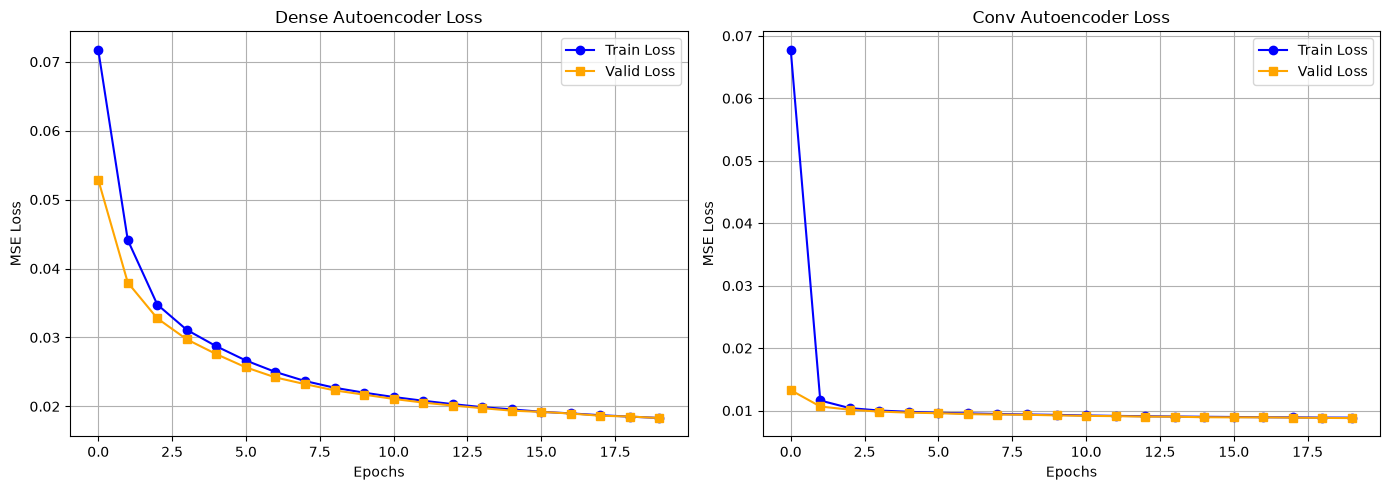

In [35]:
# Plotting Loss Function Graphs
fig,axes=plt.subplots(1,2,figsize=(14,5))

# Dense Autoencoder Loss Plot
axes[0].plot(loss_dense['train'],label='Train Loss',color='blue',marker='o')
axes[0].plot(loss_dense['valid'],label='Valid Loss',color='orange',marker='s')
axes[0].set_title('Dense Autoencoder Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True)

# Convolutional Autoencoder Loss Plot
axes[1].plot(loss_conv['train'],label='Train Loss',color='blue',marker='o')
axes[1].plot(loss_conv['valid'],label='Valid Loss',color='orange',marker='s')
axes[1].set_title('Conv Autoencoder Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

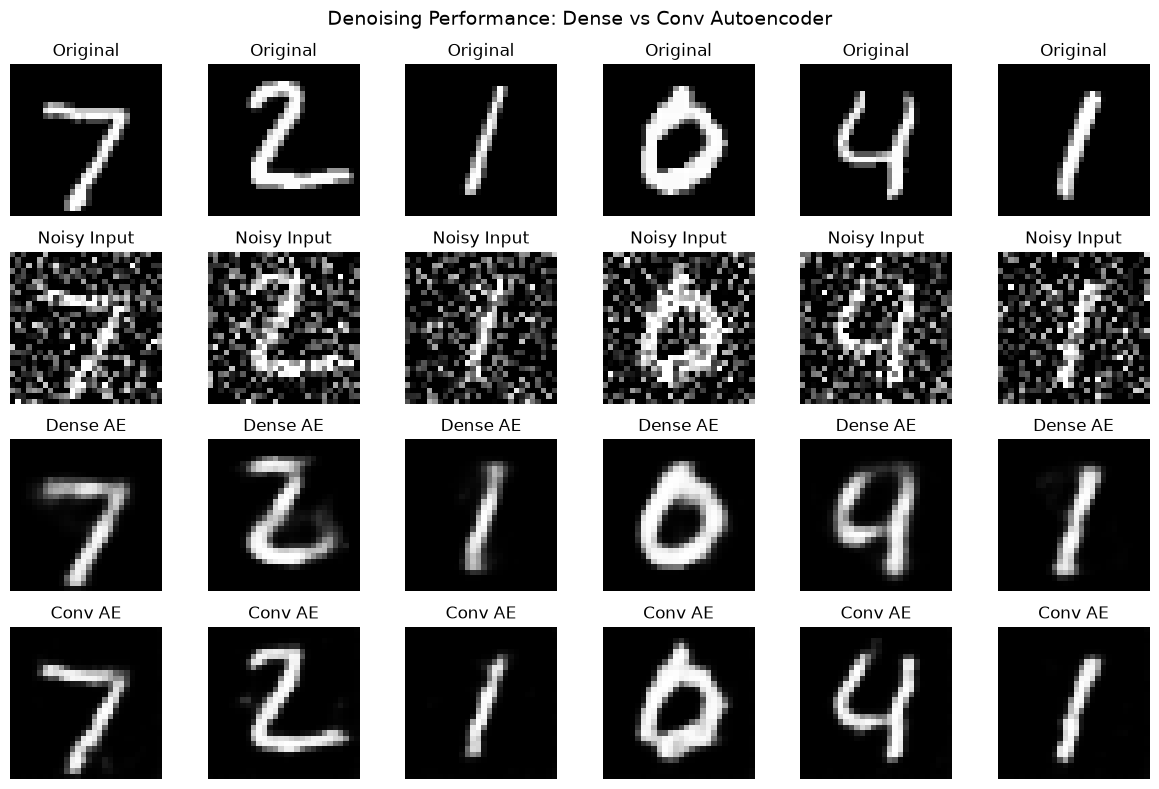

In [36]:
model_dense.eval()
model_conv.eval()

eval_imgs=test_imgs[:6].to(dev)
eval_noisy=noisy_test_imgs[:6].to(dev)

with torch.no_grad():
    out_dense=model_dense(eval_noisy)
    out_conv=model_conv(eval_noisy)

fig,axes=plt.subplots(4,6,figsize=(12,8))
fig.suptitle('Denoising Performance: Dense vs Conv Autoencoder',fontsize=14)
for i in range(6):
    #Original Images
    axes[0,i].imshow(eval_imgs[i].cpu().squeeze(),cmap='gray')
    axes[0,i].set_title("Original")
    axes[0,i].axis('off')

    #Noisy Input
    axes[1,i].imshow(eval_noisy[i].cpu().squeeze(),cmap='gray')
    axes[1,i].set_title("Noisy Input")
    axes[1,i].axis('off')

    #Dense Autoencoder Output
    axes[2,i].imshow(out_dense[i].cpu().squeeze(),cmap='gray')
    axes[2,i].set_title("Dense AE")
    axes[2,i].axis('off')

    #Convolutional Autoencoder Output
    axes[3,i].imshow(out_conv[i].cpu().squeeze(),cmap='gray')
    axes[3,i].set_title("Conv AE")
    axes[3,i].axis('off')

plt.tight_layout()
plt.show()

## 6. Noise Level Experiment and PSNR Analysis


In [46]:
import math

def calculate_psnr(original,reconstructed):
    mse=torch.mean((original-reconstructed)**2)
    if mse.item()==0:
        return 100
    return 20*math.log10(1.0/math.sqrt(mse.item()))

Noise Level Experiment

- Different Gaussian noise levels are applied to the test images.
- Both autoencoder models are tested using the same noisy inputs.
- PSNR values are calculated for each noise level.
- The results help compare the robustness of both models under different noise conditions.

In [ ]:
noise_levels=[0.2,0.4,0.6]
imgs=test_imgs[:6].to(dev)
print("PSNR Comparison\n")

for level in noise_levels:
    noisy=torch.clamp(imgs+level*torch.randn_like(imgs),0,1 )

    with torch.no_grad():
        dense_out=model_dense(noisy)
        conv_out=model_conv(noisy)

    dense_psnr=calculate_psnr(imgs,dense_out)
    conv_psnr=calculate_psnr(imgs,conv_out)

    print(f"Noise Level : {level}")
    print(f"DenseAutoencoder PSNR : {dense_psnr:.2f} dB")
    print(f"ConvAutoencoder PSNR : {conv_psnr:.2f} dB")
    print("-"*35)

PSNR Comparison

Noise Level : 0.2
DenseAutoencoder PSNR : 19.24 dB
ConvAutoencoder PSNR : 25.92 dB
-----------------------------------
Noise Level : 0.4
DenseAutoencoder PSNR : 19.04 dB
ConvAutoencoder PSNR : 22.39 dB
-----------------------------------
Noise Level : 0.6
DenseAutoencoder PSNR : 16.81 dB
ConvAutoencoder PSNR : 16.61 dB
-----------------------------------


PSNR Analysis

- PSNR is used to measure the quality of the reconstructed images.
- A higher PSNR value indicates better image reconstruction.
- The Convolutional AutoEncoder performed better than the Dense AutoEncoder at noise levels **0.2** and **0.4**.
- At a noise level of **0.6**, both models showed similar performance because the images contained heavy noise.
- Overall, the Convolutional AutoEncoder achieved better denoising performance.

## Conclusion

- In this project, both the Dense AutoEncoder and Convolutional AutoEncoder were successfully trained to remove Gaussian noise from MNIST images.
- Based on the loss curves, reconstructed images, and PSNR values, the Convolutional AutoEncoder performed better than the Dense AutoEncoder at low and medium noise levels.
- At a high noise level (0.6), the performance of both models decreased, showing that heavy noise makes image reconstruction more difficult.
- Overall, the Convolutional AutoEncoder produced better image reconstruction and proved to be more effective for the image denoising task on the MNIST dataset.